![logo](img/itq.png)

## Tarea

![logo](img/python_logo.png)

*Anderson Soto*


# Prediccion de Digitos - MNIST

In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from PIL import Image

print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


## Carga del dataset

In [2]:
mnist = tf.keras.datasets.mnist
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()

print('Entrenamiento:', x_train_full.shape)
print('Prueba:', x_test.shape)

Entrenamiento: (60000, 28, 28)
Prueba: (10000, 28, 28)


## Preprocesamiento

In [3]:
# Normalizacion
x_train_norm = x_train_full / 255.0
x_test_norm  = x_test / 255.0

# One-hot encoding
y_train_ohe = to_categorical(y_train_full, num_classes=10)
y_test_ohe  = to_categorical(y_test, num_classes=10)

# Division en entrenamiento y validacion
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_norm, y_train_ohe,
    test_size=0.2,
    random_state=42
)

total = x_tr.shape[0] + x_val.shape[0] + x_test_norm.shape[0]
print(f'Entrenamiento : {x_tr.shape[0]} ({x_tr.shape[0]/total*100:.1f}%)')
print(f'Validacion    : {x_val.shape[0]} ({x_val.shape[0]/total*100:.1f}%)')
print(f'Prueba        : {x_test_norm.shape[0]} ({x_test_norm.shape[0]/total*100:.1f}%)')

Entrenamiento : 48000 (68.6%)
Validacion    : 12000 (17.1%)
Prueba        : 10000 (14.3%)


## Modelo

In [4]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

C:\Users\Rodrigo\anaconda3\envs\machine2026\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

In [5]:
H = model.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=128
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9121 - loss: 0.2934 - val_accuracy: 0.9607 - val_loss: 0.1298
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9629 - loss: 0.1222 - val_accuracy: 0.9683 - val_loss: 0.1008
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9728 - loss: 0.0872 - val_accuracy: 0.9732 - val_loss: 0.0875
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9777 - loss: 0.0679 - val_accuracy: 0.9778 - val_loss: 0.0779
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9820 - loss: 0.0545 - val_accuracy: 0.9771 - val_loss: 0.0761
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9844 - loss: 0.0479 - val_accuracy: 0.9776 - val_loss: 0.0782
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9869 - loss: 0.0402 - val_accuracy: 0.9792 - val_loss: 0.0731
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9879 - loss: 0.0360 - val_a

## Curvas de entrenamiento

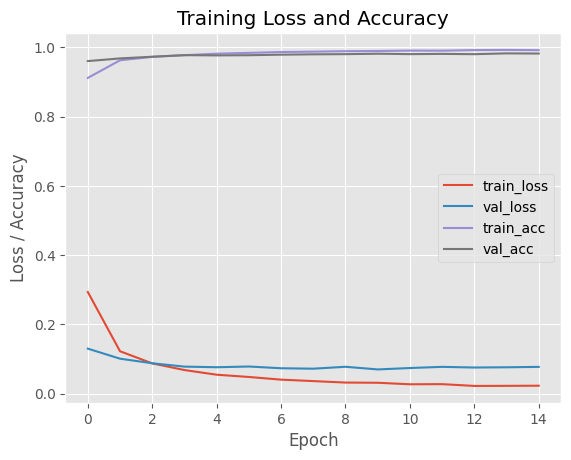

In [6]:
plt.style.use('ggplot')
plt.figure()
plt.plot(H.history['loss'],         label='train_loss')
plt.plot(H.history['val_loss'],     label='val_loss')
plt.plot(H.history['accuracy'],     label='train_acc')
plt.plot(H.history['val_accuracy'], label='val_acc')
plt.title('Training Loss and Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss / Accuracy')
plt.legend()
plt.show()

## Evaluacion en conjunto de prueba

In [7]:
loss, acc = model.evaluate(x_test_norm, y_test_ohe, verbose=0)
print(f'Loss prueba     : {loss:.4f}')
print(f'Accuracy prueba : {acc*100:.2f}%')

predictions = model.predict(x_test_norm, verbose=0)
print(classification_report(y_test_ohe.argmax(axis=1), predictions.argmax(axis=1)))

Loss prueba     : 0.0791
Accuracy prueba : 98.04%
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.96      0.99      0.97      1010
           4       0.99      0.97      0.98       982
           5       0.98      0.97      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## Prediccion con imagen propia

Coloca tu imagen en la misma carpeta del notebook y cambia el nombre en la variable `RUTA_IMAGEN`.

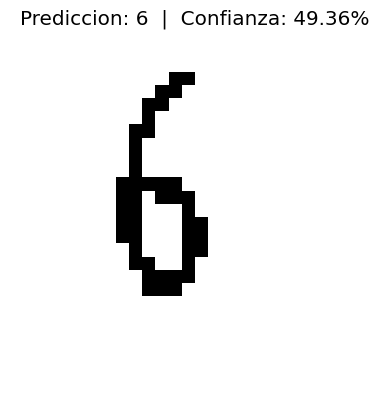

Digito predicho : 6
Confianza       : 49.36%

Probabilidades por digito:
  0: 0.01%
  1: 0.00%
  2: 0.00%
  3: 0.00%
  4: 3.46%
  5: 0.71%
  6: 49.36%
  7: 0.00%
  8: 46.46%
  9: 0.00%


In [12]:
RUTA_IMAGEN = 'img/numero_seis.png'

img = Image.open(RUTA_IMAGEN).convert('L').resize((28, 28), Image.LANCZOS)
img_array = np.array(img).astype(np.float32)

# Normalizar al rango 0-1
img_array = img_array / 255.0

# Binarizacion con umbral de Otsu para limpiar el fondo
from skimage.filters import threshold_otsu
umbral = threshold_otsu(img_array)
img_bin = (img_array > umbral).astype(np.float32)

# Asegurarse de que el fondo sea 0 y el digito sea 1
if img_bin.mean() > 0.5:
    img_bin = 1.0 - img_bin

# Predecir
probs  = model.predict(np.expand_dims(img_bin, axis=0), verbose=0)[0]
digito = probs.argmax()

plt.imshow(img_bin, cmap='gray_r')
plt.title(f'Prediccion: {digito}  |  Confianza: {probs[digito]*100:.2f}%')
plt.axis('off')
plt.show()

print(f'Digito predicho : {digito}')
print(f'Confianza       : {probs[digito]*100:.2f}%')
print()
print('Probabilidades por digito:')
for i, p in enumerate(probs):
    print(f'  {i}: {p*100:.2f}%')

## Github


https://github.com/Joji-free/machine2026.git